In [1]:
import torch
import torch.nn as nn

CNN은 nn.Conv2d를 사용  
nn.Conv2d(  
    &nbsp; in_channels=인풋 채널 수,  
    &nbsp; out_channels=나오는 필터의 수,  
    &nbsp; kernel_size=필터(커널 사이즈)  
)


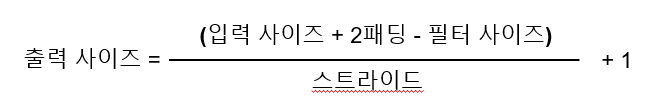

## Lenet 모델 구조

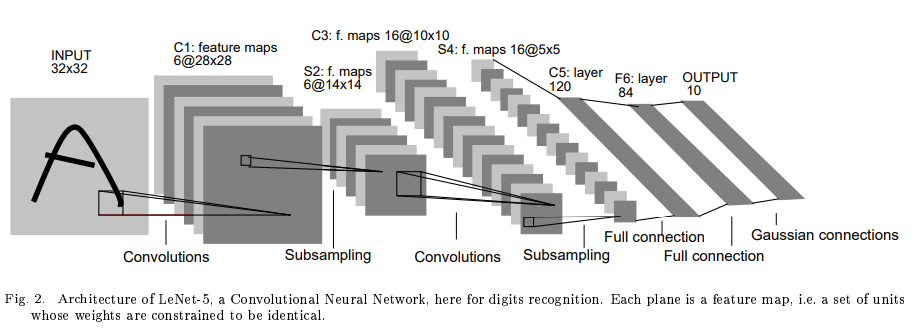

In [2]:
class Lenet(nn.Module):
  def __init__(self):
    super(Lenet, self).__init__()
    # 처음 in_channels = 채널의 개수 = 1개(흑백)
    # out_channels = 나오는 필터의 수
    # 32*32 흑백 이미지와 5*5 필터 6개가 합성곱 연산 -> 28*28 크기의 특징맵 6개가 만들어진다.
    self.c1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
    # cnn도 활성화함수 필요함. lenet은 tanh 씀
    self.act1 = nn.Tanh()
    # 풀링(이미지 줄이기. 특징 수는 똑같) maxpooling = subsampling
    self.s2 = nn.MaxPool2d(kernel_size=2)
    # 14*14 특징맵 6개와 5*5 필터 16개가 합성곱 연산 -> 10*10 크기의 특징맵 16개가 만들어진다.
    self.c3 = nn.Conv2d(in_channels=6,out_channels=16, kernel_size=5)
    self.act2 = nn.Tanh()
    self.s4 = nn.MaxPool2d(kernel_size=2)

    # 5*5 특징맵 16개와 5*5 필터 120개가 합성곱 연산 -> 1*1 크기의 특징맵 120개가 만들어진다
    self.c5 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5)
    self.act3 = nn.Tanh()

    self.fc6 = nn.Linear(120, 84)
    self.act4 = nn.Tanh()
    self.output = nn.Linear(84,10)
    self.act5 = nn.Tanh()

  def forward(self, x):
    x = self.c1(x)
    x = self.act1(x)
    x = self.s2(x)

    x = self.c3(x)
    x = self.act2(x)
    x = self.s4(x)

    x = self.c5(x)
    x = self.act3(x)

    x = x.view(-1, 120) # (-1, 120) * (120, 84) -> (-1, 84)
    x = self.fc6(x)
    x = self.act4(x)
    x = self.output(x)
    x = self.act5(x)

    return x

In [3]:
model = Lenet()
model

Lenet(
  (c1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (act1): Tanh()
  (s2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (act2): Tanh()
  (s4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c5): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (act3): Tanh()
  (fc6): Linear(in_features=120, out_features=84, bias=True)
  (act4): Tanh()
  (output): Linear(in_features=84, out_features=10, bias=True)
  (act5): Tanh()
)

In [4]:
# test
data = torch.rand(1,32,32)

In [5]:
data.shape

torch.Size([1, 32, 32])

In [6]:
model(data).shape

torch.Size([1, 10])

In [7]:
data = torch.rand(32,1,32,32)
model(data).shape

torch.Size([32, 10])

# lenet-5와 MNIST 학습

In [9]:
from torchvision.datasets import MNIST # 데이터셋
import torchvision.transforms as transforms # 전처리
from torch.utils.data import DataLoader # 데이터로더
from torch.optim import Adam # 최적화함수
import matplotlib.pyplot as plt

In [10]:
# 전처리
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(32),
    transforms.Normalize((0.5,),(1.0,))
])

In [11]:
# 데이터셋 다운
train_data = MNIST(root='./data', train=True, download=True, transform=data_transform)
test_data = MNIST(root='./data', train=False, download=True, transform=data_transform)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.99MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [12]:
# 데이터로더로 변환
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [13]:
len(train_loader), len(test_loader)

(1875, 313)

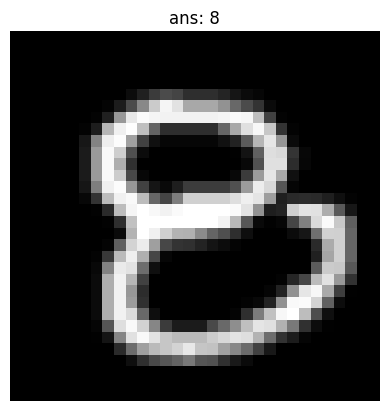

In [14]:
# 데이터로더 확인
def imgshow(tensor_array, title, cmap=None):
  numpy_array = tensor_array.numpy()
  img = numpy_array.transpose(1,2,0)
  plt.axis('off')
  plt.title(title)
  plt.imshow(img, cmap=cmap)

data, target = next(iter(train_loader)) # 32개 들어있음
imgshow(data[0], title=f'ans: {target[0].item()}', cmap='gray')


In [15]:
# 모델에 데이터 넣고 확인
model(data)

tensor([[ 2.7005e-02,  6.1819e-02,  3.1401e-02, -5.1562e-02, -7.2155e-03,
          5.3656e-02,  8.3535e-02,  4.8031e-02, -6.6099e-02,  5.8803e-02],
        [ 6.5663e-02,  6.8983e-02,  4.8607e-02, -8.9691e-02, -4.8492e-02,
          4.2277e-02,  9.1324e-02,  3.3251e-02, -7.9819e-02,  4.4182e-02],
        [ 4.5605e-02,  5.0804e-02,  3.7472e-02, -5.2210e-02, -2.6223e-03,
          6.2379e-02,  1.0316e-01,  3.0058e-02, -7.3825e-02,  1.9960e-02],
        [ 1.3471e-02,  5.1592e-02,  4.7744e-02, -3.6668e-02,  1.1850e-02,
          5.6502e-02,  9.5837e-02,  3.5188e-02, -5.3715e-02,  4.8297e-02],
        [ 3.0802e-02,  5.7629e-02,  4.9364e-03, -6.4457e-02,  3.2486e-04,
          7.8596e-02,  1.0076e-01,  4.2225e-02, -5.9328e-02,  4.4138e-02],
        [ 4.5100e-02,  6.0422e-02,  9.7079e-03, -3.9041e-02,  8.7095e-04,
          4.8452e-02,  1.1239e-01,  4.8328e-02, -7.2398e-02,  4.8553e-02],
        [ 2.9804e-02,  7.1565e-02,  4.4732e-02, -3.4011e-02,  4.4768e-04,
          6.0024e-02,  9.0985e-0

# 모델 학습

In [16]:
# 최적화함수
optimizer = Adam(model.parameters(), lr=0.001)
# 손실함수
criterion = nn.CrossEntropyLoss()
# 에폭
epochs = 10

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [19]:
model.to(device)

Lenet(
  (c1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (act1): Tanh()
  (s2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (act2): Tanh()
  (s4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c5): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (act3): Tanh()
  (fc6): Linear(in_features=120, out_features=84, bias=True)
  (act4): Tanh()
  (output): Linear(in_features=84, out_features=10, bias=True)
  (act5): Tanh()
)

### 기울기 초기화 시점
배치 수준에서 기울기 초기화하는 이유는, 각 배치마다 독립적으로 파라미터 업데이트가 이루어져야 하기 때문입니다. 즉, 각 배치에서 계산된 기울기를 그 배치에만 적용하고, 다음 배치의 기울기가 이전 배치의 영향을 받지 않도록 해야 합니다

In [20]:
model.train()

loss_list = []
min_loss = int(1e9)
for epoch in range(epochs):
  losses = 0
  for data, target in train_loader:
    optimizer.zero_grad() # 배치마다 기울기 초기화(각 배치의 정보에 맞게 가중치 업데이트를 위해)
    y_pred = model(data.to(device))
    loss = criterion(y_pred, target.to(device))
    losses += loss.item()
    loss.backward()
    optimizer.step()
  avg_loss = losses/len(train_loader) # 배치 별 손실 값 평균
  loss_list.append(avg_loss) # 에폭 별 손실 값 리스트에 저장
  print(f'epoch: {epoch+1}, loss: {avg_loss}')
  if avg_loss < min_loss: # 손실 값이 최저일 때만 저장
    torch.save(model.state_dict(), f'model{epoch+1}.pth') # 모델 가중치 저장
    min_loss = avg_loss # 최소 손실 값 갱신

epoch: 1, loss: 0.9116640058199564
epoch: 2, loss: 0.8306070289293925
epoch: 3, loss: 0.8214220095316569
epoch: 4, loss: 0.8170688401858012
epoch: 5, loss: 0.8137465834935507
epoch: 6, loss: 0.8116817620277404


KeyboardInterrupt: 

## 모델 검증

In [27]:
model.eval()
correct = 0 # 맞춘 수
total = 0 # 데이터 수

with torch.no_grad():
  for data, target in test_loader:
    y_pred = model(data.to(device))
    result = y_pred.max(dim=1)[1]
    correct += sum(result==target.to(device)).item()
    total += target.size(0)
print(f'accuracy: {correct/total}')

accuracy: 0.9872


In [28]:
torch.save(model.state_dict(), 'mnist_lenet.pth')

## 모델 불러오기

In [2]:
import torch
from torch import nn
# 클래스 그대로
class Lenet(nn.Module):
  def __init__(self):
    super(Lenet, self).__init__()
    # 처음 in_channels = 채널의 개수 = 1개(흑백)
    # out_channels = 나오는 필터의 수
    # 32*32 흑백 이미지와 5*5 필터 6개가 합성곱 연산 -> 28*28 크기의 특징맵 6개가 만들어진다.
    self.c1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
    # cnn도 활성화함수 필요함. lenet은 tanh 씀
    self.act1 = nn.Tanh()
    # 풀링(이미지 줄이기. 특징 수는 똑같) maxpooling = subsampling
    self.s2 = nn.MaxPool2d(kernel_size=2)
    # 14*14 특징맵 6개와 5*5 필터 16개가 합성곱 연산 -> 10*10 크기의 특징맵 16개가 만들어진다.
    self.c3 = nn.Conv2d(in_channels=6,out_channels=16, kernel_size=5)
    self.act2 = nn.Tanh()
    self.s4 = nn.MaxPool2d(kernel_size=2)

    # 5*5 특징맵 16개와 5*5 필터 120개가 합성곱 연산 -> 1*1 크기의 특징맵 120개가 만들어진다
    self.c5 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5)
    self.act3 = nn.Tanh()

    self.fc6 = nn.Linear(120, 84)
    self.act4 = nn.Tanh()
    self.output = nn.Linear(84,10)
    self.act5 = nn.Tanh()

  def forward(self, x):
    x = self.c1(x)
    x = self.act1(x)
    x = self.s2(x)

    x = self.c3(x)
    x = self.act2(x)
    x = self.s4(x)

    x = self.c5(x)
    x = self.act3(x)

    x = x.view(-1, 120) # (-1, 120) * (120, 84) -> (-1, 84)
    x = self.fc6(x)
    x = self.act4(x)
    x = self.output(x)
    x = self.act5(x)

    return x

In [3]:
model = Lenet()
model

Lenet(
  (c1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (act1): Tanh()
  (s2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (act2): Tanh()
  (s4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c5): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (act3): Tanh()
  (fc6): Linear(in_features=120, out_features=84, bias=True)
  (act4): Tanh()
  (output): Linear(in_features=84, out_features=10, bias=True)
  (act5): Tanh()
)

In [5]:
model.load_state_dict(torch.load('mnist_lenet.pth', map_location=torch.device('cpu')))

<ipython-input-5-19b68707ecb0>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('mnist_lenet.pth', map_location=torch.device('cpu')))


<All keys matched successfully>

## 필터 가중치 추출 및 시각화

In [6]:
model

Lenet(
  (c1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (act1): Tanh()
  (s2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (act2): Tanh()
  (s4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c5): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (act3): Tanh()
  (fc6): Linear(in_features=120, out_features=84, bias=True)
  (act4): Tanh()
  (output): Linear(in_features=84, out_features=10, bias=True)
  (act5): Tanh()
)

In [7]:
type(model.c5.weight) # torch.nn.Parameter 객체(.data와 .grad 속성 가짐)

torch.nn.parameter.Parameter

In [8]:
type(model.c5.weight.data) # 순수 텐서 값

torch.Tensor

In [9]:
# 120개의 필터가 있다
# 16개의 입력 채널(특징맵)
# 5*5 크기
# 120개의 5*5 필터가 있고, 각 필터는 16개의 채널에 대해 합성곱 연산을 한다
model.c5.weight.data.shape

torch.Size([120, 16, 5, 5])

In [14]:
import matplotlib.pyplot as plt

## 각 필터의 첫 번째 채널 확인(입력 채널 중 첫 번째 채널과 해당 필터가 만나는 부분을 시각화)

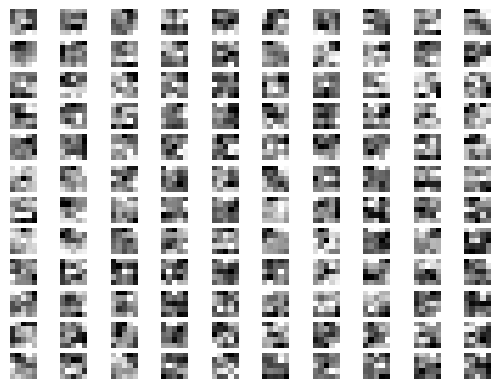

In [37]:
def visualize_filters(layer, num_cols):
    filters = layer.weight.data.clone() # 가중치 텐서 가져오기(원본 텐서는 변하지 않도록 복사)

    # 필터를 그리드로 배치하기 위해 적절한 수 계산
    num_filters = filters.shape[0] # 120
    num_channels = filters.shape[1] # 16
    # num_cols = 10  # 10열로 시각화
    num_rows = (num_filters + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols) # 행, 열

    # 필터 이미지 그리기
    for i, ax in enumerate(axes.flat): # 인덱스와 축 객체를 순회
        if i < num_filters: # 필터 수보다 축 수가 많을 수도 있어서 조건문 걸기
            # 각 필터의 첫 번째 채널만 시각화 (GrayScale)
            img = filters[i, 0, :, :].numpy()
            ax.imshow(img, cmap='gray')
        ax.axis('off')

    plt.show()

# c5 레이어의 필터 시각화
# 5*5 특징맵 16개와 5*5 필터 120개가 합성곱 연산 -> 1*1 크기의 특징맵 120개가 만들어진다
# 5*5 16개와 1개의 5*5 필터 하나를 계산해서 더함 * 120 번
visualize_filters(model.c5.to('cpu'), 10)

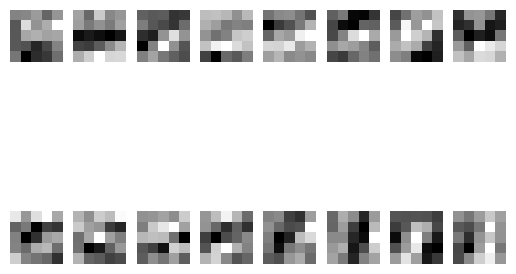

In [38]:
visualize_filters(model.c3.to('cpu'),8)

### subplot 도움

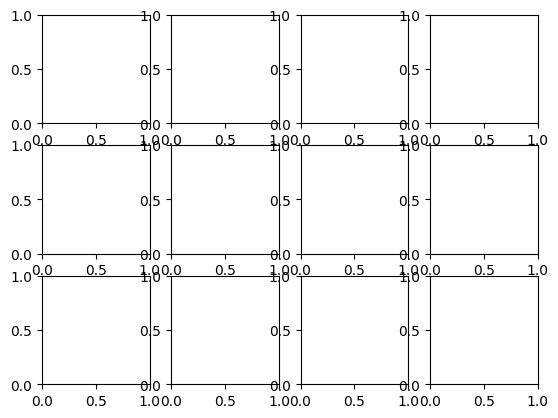

In [15]:
fig, axes = plt.subplots(3,4)

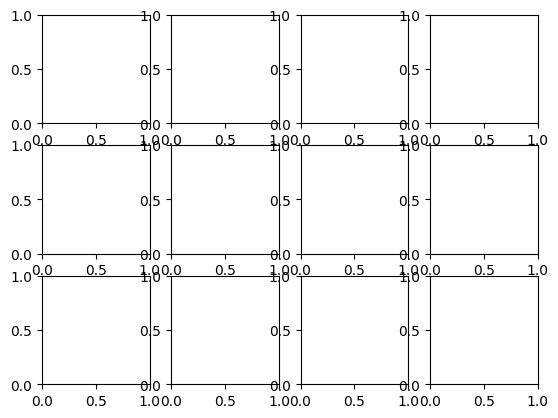

In [16]:
fig

In [17]:
axes

array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [18]:
axes.flat

In [19]:
for i, ax in enumerate(axes.flat):
  print(i, ax)

0 Axes(0.125,0.653529;0.168478x0.226471)
1 Axes(0.327174,0.653529;0.168478x0.226471)
2 Axes(0.529348,0.653529;0.168478x0.226471)
3 Axes(0.731522,0.653529;0.168478x0.226471)
4 Axes(0.125,0.381765;0.168478x0.226471)
5 Axes(0.327174,0.381765;0.168478x0.226471)
6 Axes(0.529348,0.381765;0.168478x0.226471)
7 Axes(0.731522,0.381765;0.168478x0.226471)
8 Axes(0.125,0.11;0.168478x0.226471)
9 Axes(0.327174,0.11;0.168478x0.226471)
10 Axes(0.529348,0.11;0.168478x0.226471)
11 Axes(0.731522,0.11;0.168478x0.226471)


## 필터의 채널 확인

In [21]:
# 16개
model.c5.weight.data[0].shape

torch.Size([16, 5, 5])

1. 입력 채널 16개가 있다고 가정합시다. 각 채널은 5x5 크기의 특징맵을 가집니다.

2. 120개의 필터가 있는데, 각 필터는 16개의 채널을 처리할 수 있습니다. 

즉, 각 필터는 16개의 채널에 대해 각각 5x5 크기의 가중치를 갖고 있습니다.
필터 A(첫 번째 필터)는 실제로 16개의 작은 5x5 크기 필터들로 이루어져 있습니다.
필터 A에는 16개의 필터가 각 입력 채널에 대응되어 있으며, 각각의 필터는 해당 채널에 대해 합성곱 연산을 수행합니다.

3. 합성곱 연산:

채널 1과 필터 1을 합성곱하여 첫 번째 값을 얻고,
채널 2와 필터 2를 합성곱하여 두 번째 값을 얻고,
채널 16과 필터 16을 합성곱하여 열 여섯 번째 값을 얻습니다.
이 연산이 끝나면 1x1 크기의 특징맵이 16개 만들어집니다. 이는 채널 1~16 각각에 대한 결과물입니다.

4. 결과 결합:

이렇게 16개의 1x1 크기 특징맵이 생성되면, 이들을 모두 합쳐서 하나의 1x1 특징맵을 얻을 수 있습니다. 그리고 이것이 첫 번째 필터의 결과입니다.

5. 최종 결과:

120개의 필터에 대해 각각 이와 같은 합성곱 연산을 수행한 후, 120개의 1x1 특징맵이 만들어집니다.
이 결과가 120개의 채널로 이루어진 새로운 특징맵을 형성하게 됩니다.

## 요약:
입력 채널 16개와 120개의 필터가 주어졌을 때, 각 필터는 16개의 입력 채널에 대해 16개의 5x5 필터를 가지고 있습니다.
각 채널과 각 필터의 합성곱 연산을 통해 1x1 크기의 16개 값이 계산되고, 이 16개 값을 합쳐 하나의 1x1 특징맵을 만듭니다.
이런 방식으로 120개의 필터를 모두 적용하여 120개의 1x1 특징맵이 생성되고, 그 결과가 새로운 출력 특징맵이 됩니다.

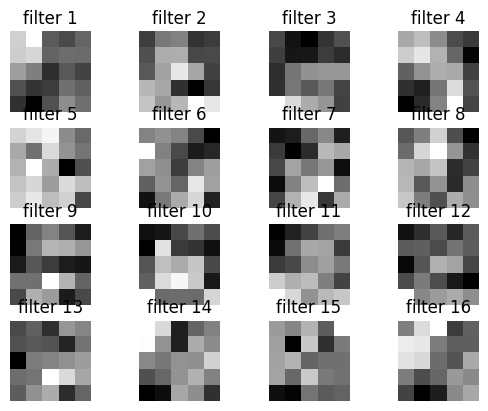

In [34]:
# 120개의 필터 중 첫 번째 필터에 해당하는 16개의 채널을 시각적으로 확인
fig, axes = plt.subplots(4,4)
for i, ax in enumerate(axes.flat):
  ax.imshow(num_array, cmap='gray')
  ax.axis('off')
  num_array = model.c5.weight.data[0][i].numpy()
  ax.set_title(f'filter {i+1}')
plt.show()